# Chronos-2 vs Baselines: Does a Time-Series Foundation Model Beat the Generalists?

**Neil Docherty—DT2 Niche GenAI Assignment—May 2026**

I tested a specialist time-series foundation model ([Chronos-2](https://huggingface.co/amazon/chronos-2)) head-to-head against classical methods, gradient-boosted ML, and three general-purpose chatbots, all forecasting bike-share demand. The three sections below mirror the assignment brief.

- **Part 1**: discovery and selection
- **Part 2**: testing and documentation
- **Part 3**: critical assessment

To reproduce: `uv sync && jupyter nbconvert --execute notebooks/03_report.ipynb`. Heavy forecasts cache to `outputs/forecasts/` so that reruns are quicker.

## Terminology

Some specialist terms for reference.

- **Foundation model**: a large model pre-trained on broad data, intended to be used zero-shot or with light adaptation on downstream tasks. Borrowed from the LLM world; applied here to *time-series* foundation models (Chronos-2, TimesFM, Moirai), which are pre-trained on numeric series rather than text.
- **Zero-shot forecasting**: generating a forecast on a series the model has never seen, with no fitting or fine-tuning. The opposite of classical forecasting where you fit a model per series.
- **Covariate**: an external variable that helps explain the target. Here: weather (temperature, humidity, wind), calendar (hour, weekday, holiday). Chronos-2 v2's main new feature is accepting *future* covariates at prediction time.
- **Quantile / probabilistic forecast**: instead of a single point prediction, the model returns multiple quantiles. We use **q10 / q50 / q90**: median (q50) plus the 10th and 90th percentile, which together bound an 80% prediction interval.
- **Prediction interval (PI)**: a range expected to contain the true value with a given probability. An 80% PI should contain the actual outcome ~80% of the time across many forecasts. Wider than necessary = under-confident; too narrow = over-confident.
- **MASE** (Mean Absolute Scaled Error): point-forecast error scaled by the in-sample seasonal-naive baseline. **MASE < 1 means the model beats a seasonal naive**; MASE = 1 ties it.
- **MAPE** (Mean Absolute Percentage Error): the familiar "on average we're off by X%" metric. Easy to read but blows up when actual values are near zero (e.g. overnight bike rentals), so used here only as a sanity check.
- **WQL** (Weighted Quantile Loss): probabilistic error metric averaged across all forecast quantiles. **Lower is better.** Penalises both bias and miscalibrated intervals. The single most informative number in this report.
- **Coverage**: empirical hit rate of the prediction interval. For an 80% PI the target is 0.80. Below = over-confident, above = under-confident.
- **Calibration**: whether stated uncertainty matches realised error rates. A well-calibrated 80% PI has coverage near 0.80.
- **Subprocess isolation**: running each forecaster in its own fresh Python process. Used here because LightGBM and PyTorch (which Chronos-2 depends on) ship incompatible OpenMP runtimes that deadlock when loaded into the same Python kernel on macOS.
- **Niche GenAI** (assignment-specific): a generative-AI tool that delivers specialised value beyond what a general-purpose chatbot can offer, by being purpose-built for a specific domain or task.

## Part 1—Discovery and selection

### The tool

[**Chronos-2**](https://huggingface.co/amazon/chronos-2) is Amazon Science's 120M-parameter time-series foundation model, released October 2025 with Apache-2.0 weights. Under the hood it uses the encoder half of [Google's T5 transformer architecture](https://arxiv.org/abs/1910.10683) (the same family of models that originally powered text translation and summarisation), but retrained from scratch on numeric time series rather than text — and it can be run on a laptop CPU. Version 2 adds *covariate-informed* and *multivariate* zero-shot forecasting on top of v1's univariate models. Covariates are the focus of this report.

<figure><img src="../chatbot_comparison/screenshots/huggingface-chronos2-model-card.png" alt="Chronos-2 Hugging Face model card"><figcaption>Figure 1. Chronos-2 model card on Hugging Face — confirms Apache-2.0 weights, 120M params, and the covariate-informed v2 release.</figcaption></figure>

### Why it qualifies as *niche* GenAI

- **Not an LLM under the hood.** It shares the transformer encoder architecture with LLMs, but the weights, the tokenisation (mean-scale + quantisation), and the training data are all built for numbers, not language.
- **Open, reproducible, free.** Apache-2.0 weights on Hugging Face, peer-reviewed benchmarks (fev-bench, GIFT-Eval, Chronos Benchmark II), no API key, no network needed at inference.
- **Why it matters for a business.** Forecasting is one of the most common analytics asks, and most real demand isn't a single isolated series. The v2 covariate feature lets the model take in known future drivers (weather forecasts, holidays, promotions, planned price changes), and the multivariate capability lets it forecast many related series jointly — for example demand across SKUs in a category, or footfall across a chain of stores — sharing what it learns about one series with the others. Most production forecasting problems sit in exactly this shape.

### Discovery process

Browsed Hugging Face, deliberately skipping the two crowded categories where most "GenAI" tools really are just thin wrappers around an LLM or a Stable-Diffusion fork: chatbots and image/video generation. That left specialised tags like time-series, audio, protein and tabular. So I picked time-series: forecasting is an everyday business problem and a daily fixture of analytics work. Chronos-2 stood out: it was clearly *not* an LLM, but interestingly reused some of the same architectural ideas (transformer encoder, tokenisation, pre-training at scale), the weights were open-source under Apache-2.0, and I could run it locally on my laptop without paying for an API or sending any data off-machine.

**Background reading and viewing I found useful:**
- [Amazon Science release post — Chronos-2 (Oct 2025)](https://www.amazon.science/blog/adapting-language-model-architectures-for-time-series-forecasting)
- [YouTube — Chronos-2 walkthrough](https://www.youtube.com/watch?v=wSc76uFpFKg)
- [YouTube — time-series foundation models overview](https://www.youtube.com/watch?v=PeJReI9Sm0U)

## Part 2—Testing and documentation

### Business use case

**Hourly demand forecasting for a bike-share operator.** Inputs: 22 months of hourly rental history with aligned weather and calendar covariates ([UCI Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset), also mirrored on [Kaggle](https://www.kaggle.com/datasets/aguado/bike-rental-data-set-uci); ~17.5k rows after filling 165 missing hours). Output: the next **7 days of hourly demand** with calibrated 80% prediction intervals. An operations team rebalancing fleet for the coming week needs a good idea of the upcoming demand. Weather and calendar (working days, holidays, weekends) carry most of the signal, so a model that takes those covariates as inputs should beat one that only sees past demand.

### Evaluation strategy

- **Holdout:** the final 168 hours (7 days). Held back from every method and used only for scoring.
- **Use of the held-in history:** AutoARIMA, Prophet (±weather) and LightGBM fit parameters or trees on it. Seasonal naive uses it to compute a residual standard deviation. Chronos-2 is not fine-tuned; the history is passed in as *context* at prediction time. The chatbots see only the last 14 days, pasted into the prompt.
- **Metrics:** **MASE**, **WQL**, **80% prediction-interval coverage**, plus MAPE as a secondary check. Brief lay explanations below.
- **Ten methods** in total: seven model-based forecasters all conforming to the same `Forecaster` protocol (`fit` / `predict → q10,q50,q90`), plus three chatbot baselines run manually.

| # | Method | Family | Covariates |
|---|---|---|---|
| 1 | Seasonal naive (weekly cycle) | classical | none |
| 2 | AutoARIMA (statsforecast) | classical | none |
| 3 | Prophet | classical | calendar only |
| 4 | Prophet + weather regressors | classical | calendar + weather |
| 5 | LightGBM (quantile, lag features) | ML | calendar + weather |
| 6 | **Chronos-2 univariate** | foundation model | none |
| 7 | **Chronos-2 with covariates** | foundation model | calendar + weather |
| 8 | ChatGPT (unauthenticated web UI) | general LLM chat | calendar + weather (via prompt) |
| 9 | Claude Opus 4.7 Adaptive (desktop) | general LLM chat | calendar + weather (via prompt) |
| 10 | Llama 3.1 8B (local via Ollama) | open small LLM | calendar + weather (via prompt) |

The 6 vs 7 contrast directly tests Chronos-2's covariate-conditioning claim. The 7 vs 4/5 contrast tests whether the foundation-model approach beats well-tuned classical/ML on the same information. The 7 vs 8/9/10 contrast asks whether the specialist beats the generalists at all.

### Notes

I'm primarily a TypeScript engineer with limited Python experience, so the practical question was whether the tool would actually be usable for me. Chronos-2 turned out to be a good fit: its documentation, quickstart, and examples are all in Python, which made it straightforward to wire up directly (with some help from Claude) rather than having to build an interface over an R or other-language implementation. The Python side of the work was less painful than I'd expected. There was some issue running the different models together (LightGBM and Chronos-2 deadlocked when loaded into the same process), which might be a notable constraint in a production pipeline but is likely just a skill issue on my end. I worked around it by running each model in its own subprocess.

- **Weather is observed history, not forecast.** Real deployment would degrade because weather forecasts have error. Acknowledged but not corrected.
- **Apples-to-apples on covariates.** Prophet+weather, LightGBM, Chronos-2-with-covariates, and the chatbots all received the same weather + calendar columns.
- **AutoARIMA context truncation.** AutoARIMA on 17k+ hourly observations with seasonal length 24 was prohibitively slow on CPU (>3 min). Truncated to the last 30 days of context.
- **No LightGBM hyperparameter tuning.** Defaults (`n_estimators=400, lr=0.05`). Tuning would likely improve it; the goal here was a reasonable baseline, not a tuned competitor.
- **Subprocess per forecaster.** LightGBM and Chronos-2 (PyTorch) ship incompatible OpenMP runtimes on macOS; loading both into the same Python kernel deadlocked indefinitely on first attempt. We invoke each method in a fresh process via `python -m chronos2_assessment.run_one`.
- **Chatbots run manually.** Same prompt (`chatbot_comparison/prompt.md`) pasted into each chat UI; reply extracted to CSV and scored with `chatbot_comparison/score_chatbot.py`. No API automation.

#### What the metrics mean, in plain terms

- **MASE** (Mean Absolute Scaled Error). Average absolute forecast error, divided by the average absolute error of a simple **in-sample seasonal-naive baseline**: predicting "this Tuesday at 3pm will be the same as last Tuesday at 3pm." So MASE < 1 means your model beat that trivial baseline on the training data's own seasonality; MASE = 2 means you're twice as wrong as that baseline; MASE = 8 means you've badly lost.
- **WQL** (Weighted Quantile Loss). The single most informative number in this report. It scores the **whole probabilistic forecast** (q10, q50, q90 — the low, middle and high estimates), not just the median. It penalises a model both for being wrong on average *and* for putting its uncertainty in the wrong places. Lower is better.
- **80% PI coverage** (Prediction Interval coverage). The model says "the value will land between q10 and q90 80% of the time." Coverage measures whether reality actually agrees: if the actual demand fell inside that band on 73 out of 168 hours, coverage is 0.73. Ideal is **near 0.80** — much lower means the model is overconfident (intervals too tight), much higher means it's underconfident (intervals too wide to be useful).
- **MAPE** (Mean Absolute Percentage Error). The most familiar metric to non-specialists ("on average we're off by X%"), included as a sanity check but easy to mislead with: it blows up when actual values are near zero (which happens at night with bike rentals).

#### Why these metrics

MASE, WQL, and 80% coverage are apparently the standard trio in the time-series forecasting literature (a different community to general ML, which leans on RMSE / MAE / MAPE). Three reasons for picking them here:

1. **They match what the Chronos-2 paper itself reports.** Using the same metrics means I can sanity-check my numbers against the published benchmarks rather than scoring with something the model's authors never measured against.
2. **They cover both point accuracy and probabilistic quality.** MASE handles "on average, how close was the middle forecast?" WQL and coverage handle "and was the uncertainty band the right size?" Reporting only point accuracy throws away the v2 covariate model's main selling point.
3. **MAPE is unsafe on this dataset.** Bike rentals drop to near zero overnight, and MAPE divides by the actual value — so it explodes whenever the truth is small. Included only as a familiar sanity check, not as the headline.

**Further reading:** Hyndman & Athanasopoulos, [*Forecasting: Principles and Practice*](https://otexts.com/fpp3) (chapter 5 on evaluation); the [Chronos-2 paper](https://arxiv.org/abs/2510.15821); and the [GIFT-Eval benchmark](https://github.com/SalesforceAIResearch/gift-eval), which uses the same MASE + WQL pair.

### Setup

In [1]:
import warnings, json, subprocess, sys, time
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chronos2_assessment.data_loader import load_processed
from chronos2_assessment.baselines import WEATHER_COLS, CALENDAR_COLS
from chronos2_assessment import plots as P

OUT_FIG = Path('../outputs/figures'); OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB = Path('../outputs/tables');  OUT_TAB.mkdir(parents=True, exist_ok=True)
OUT_FC  = Path('../outputs/forecasts'); OUT_FC.mkdir(parents=True, exist_ok=True)

HORIZON = 24 * 7  # 7 days
SEASON  = 24
MODEL_METHODS = [
    'seasonal_naive', 'auto_arima', 'prophet', 'prophet_weather',
    'lightgbm', 'chronos2_univariate', 'chronos2_covariates',
]
print('horizon (h):', HORIZON, '| model methods:', len(MODEL_METHODS))

horizon (h): 168 | model methods: 7


### Load and split

In [2]:
df = load_processed(Path('../data/processed'))
train = df.iloc[:-HORIZON].copy()
test  = df.iloc[-HORIZON:].copy()
actuals      = test[['timestamp', 'target']].copy()
future_cov   = test[['timestamp', 'id'] + WEATHER_COLS + CALENDAR_COLS].copy()
y_train      = train['target'].to_numpy()
print(f'train rows: {len(train):,}   test rows: {len(test)}   horizon: {HORIZON}h')
print(f'train range: {train.timestamp.min()} → {train.timestamp.max()}')
print(f'test  range: {test.timestamp.min()} → {test.timestamp.max()}')

train rows: 17,376   test rows: 168   horizon: 168h
train range: 2011-01-01 00:00:00 → 2012-12-24 23:00:00
test  range: 2012-12-25 00:00:00 → 2012-12-31 23:00:00


### Run all seven model-based forecasters (skip-if-cached)

Each method runs in its own subprocess (OpenMP isolation). Cached parquets in `outputs/forecasts/` short-circuit subsequent runs.

In [3]:
def run_method(method: str) -> dict:
    fc_path = OUT_FC / f'{method}.parquet'
    sc_path = OUT_FC / f'{method}.json'
    if fc_path.exists() and sc_path.exists():
        print(f'  cached: {method}')
    else:
        t0 = time.time()
        cmd = [sys.executable, '-m', 'chronos2_assessment.run_one',
               method, str(OUT_FC.resolve()), str(Path('../data/processed').resolve())]
        result = subprocess.run(cmd, capture_output=True, text=True, cwd='..')
        if result.returncode != 0:
            print(result.stdout); print(result.stderr)
            raise RuntimeError(f'{method} failed')
        print(f'  {method:>22}  {time.time()-t0:6.1f}s (subprocess wall)')
    return json.loads(sc_path.read_text())

scores_list = [run_method(m) for m in MODEL_METHODS]
forecasts = {m: pd.read_parquet(OUT_FC / f'{m}.parquet') for m in MODEL_METHODS}

# Include chatbot outputs scored manually via chatbot_comparison/score_chatbot.py
chatbot_methods = sorted({p.stem for p in OUT_FC.glob('*.json')} - set(MODEL_METHODS))
for m in chatbot_methods:
    scores_list.append(json.loads((OUT_FC / f'{m}.json').read_text()))
    forecasts[m] = pd.read_parquet(OUT_FC / f'{m}.parquet')
print('chatbot methods loaded:', chatbot_methods)

metrics = pd.DataFrame(scores_list)[['method', 'mase', 'wql', 'coverage_80', 'mape', 'runtime_s']]

  cached: seasonal_naive
  cached: auto_arima
  cached: prophet
  cached: prophet_weather
  cached: lightgbm
  cached: chronos2_univariate
  cached: chronos2_covariates
chatbot methods loaded: ['chatgpt_web', 'claude_opus47_desktop', 'ollama_llama31']


### Results table—all 10 methods, sorted by WQL (lower = better)

In [4]:
metrics_sorted = metrics.sort_values('wql').reset_index(drop=True)
metrics_sorted.to_csv(OUT_TAB / 'metrics.csv', index=False)
(OUT_TAB / 'metrics.md').write_text(metrics_sorted.round(3).to_markdown(index=False))
metrics_sorted.round(3)

,method,mase,wql,coverage_80,mape,runtime_s
0,chronos2_covariates,0.799,0.410,0.726,1.900,3.3
1,chatgpt_web,0.863,0.429,0.667,1.669,NaN
2,lightgbm,0.762,0.505,0.423,1.244,5.7
3,claude_opus47_desktop,1.065,0.573,0.714,1.420,NaN
4,chronos2_univariate,1.418,0.689,0.577,3.096,2.8
5,seasonal_naive,1.420,0.952,0.732,3.360,0.0
6,prophet_weather,1.819,1.002,0.637,4.499,1.5
7,prophet,1.942,1.092,0.631,5.132,1.6
8,auto_arima,2.797,1.242,0.917,14.195,82.8
9,ollama_llama31,8.362,7.418,0.125,37.814,NaN


**Reading the table.** WQL (Weighted Quantile Loss) is the main probabilistic metric: it scores the full q10/q50/q90 forecast against actuals. MASE is the main point metric (1.0 = matches the in-sample seasonal naive baseline; <1 beats it). Coverage of 0.80 is ideal—lower is over-confident, higher is under-confident.

### Metric comparison plot

Ollama (Llama 3.1 8B) is excluded from this chart because its errors are an order of magnitude larger than every other method and would flatten the rest of the bars into invisibility. See the full table above and the discussion in Part 3.

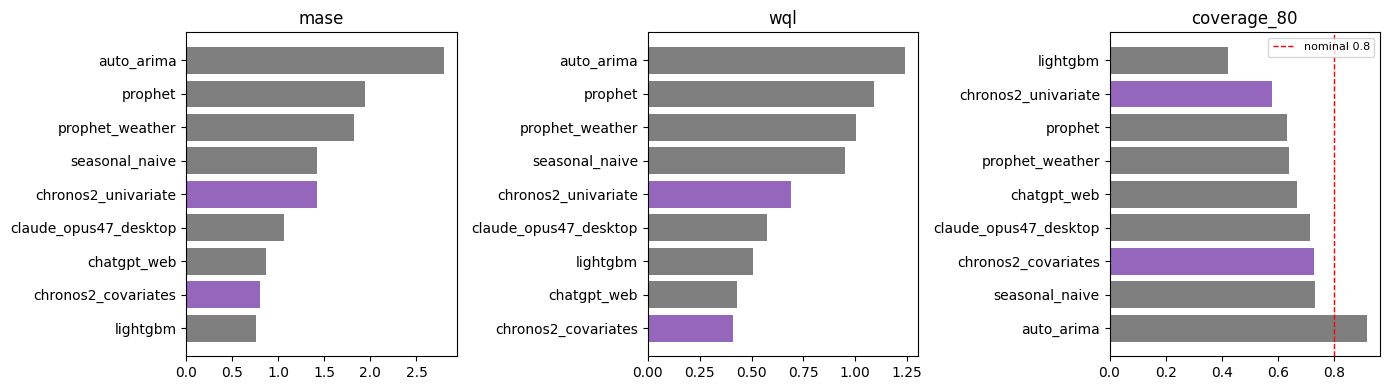

In [5]:
metrics_for_plot = metrics_sorted[metrics_sorted['method'] != 'ollama_llama31']
fig = P.plot_metric_bars(metrics_for_plot, out_path=OUT_FIG / '02_metric_bars.png')
plt.show()

### Forecast vs actual—all methods

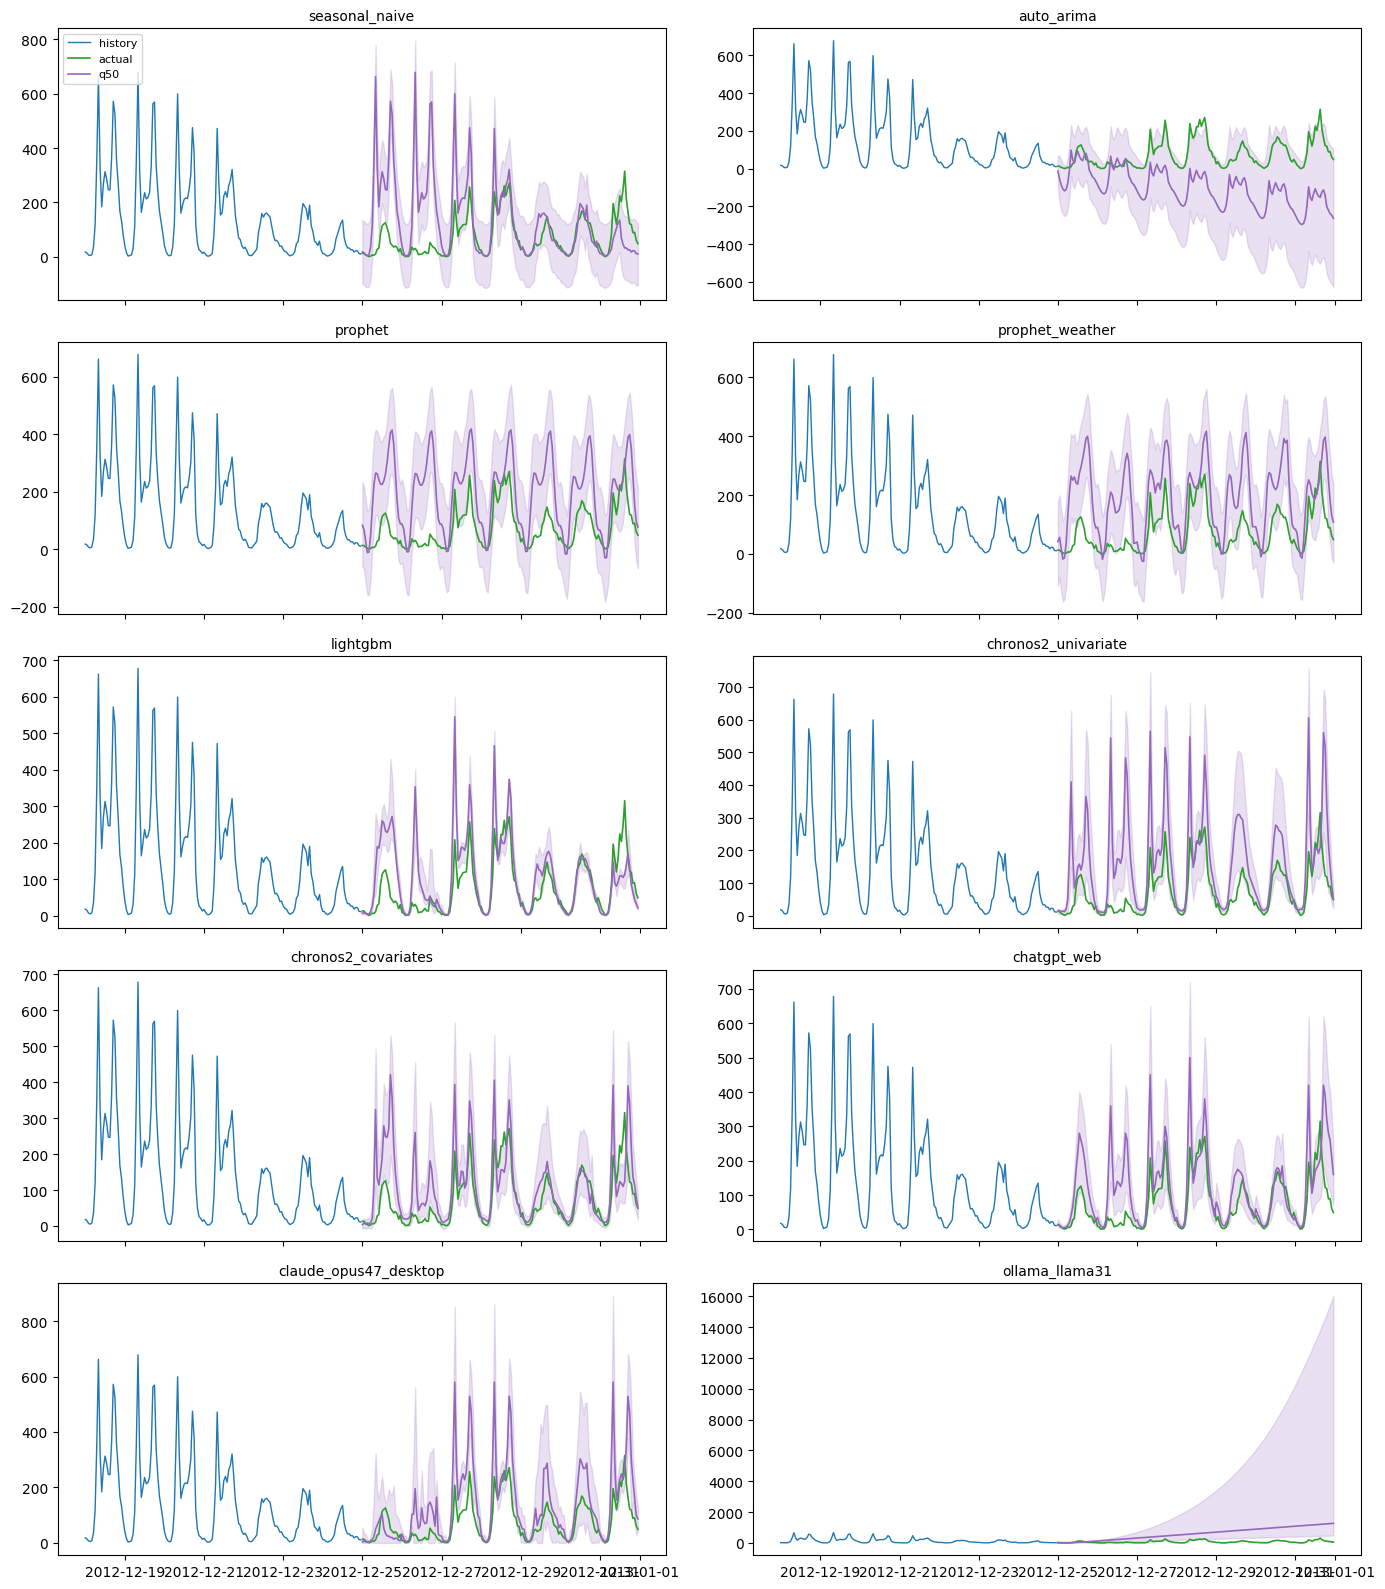

In [6]:
fig = P.plot_all_forecasts(train, forecasts, actuals,
                            history_tail=24*7,
                            out_path=OUT_FIG / '02_all_forecasts.png')
plt.show()

### Focus on: Chronos-2 univariate vs Chronos-2 + covariates

Same model, same horizon, same data. The only difference is whether the model is given the next 168 hours of weather + calendar covariates.

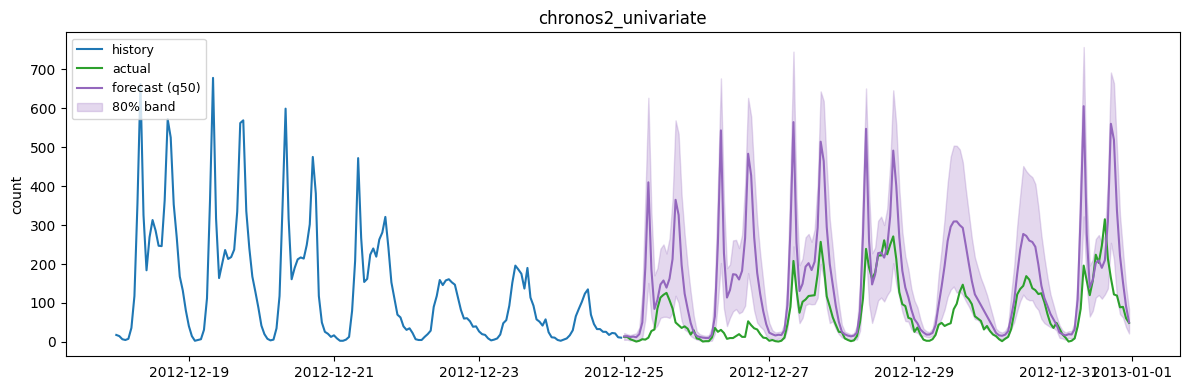

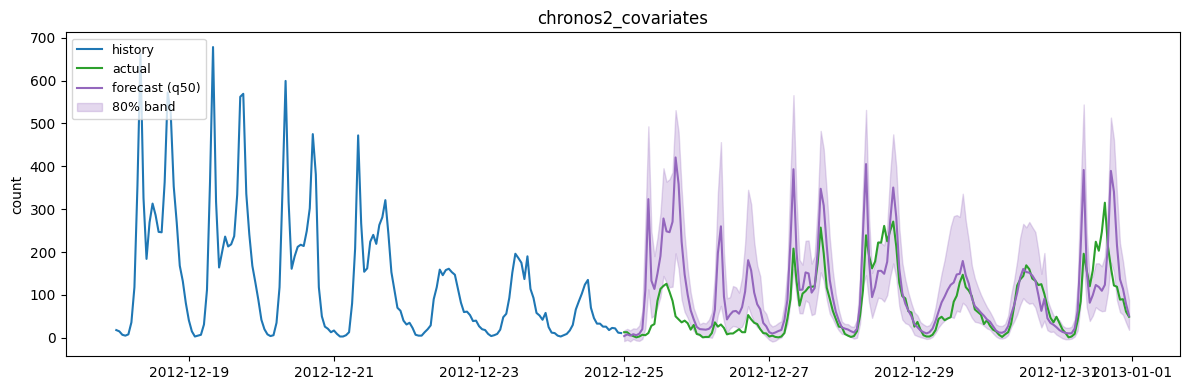

In [7]:
for name in ['chronos2_univariate', 'chronos2_covariates']:
    fig = P.plot_forecast_vs_actual(train, forecasts[name], actuals,
                                    history_tail=24*7, title=name,
                                    out_path=OUT_FIG / f'02_{name}.png')
    plt.show()

### Chatbot comparison—methodology and screenshots

To test whether the specialist beats a general-purpose chatbot, I ran the **identical task** through three chatbot tiers:

1. **ChatGPT** (unauthenticated web UI at chat.openai.com—model not disclosed by the free experience).
2. **Claude Opus 4.7 Adaptive** (Claude desktop app, paid subscription).
3. **Llama 3.1 8B** (open-weights, run locally via `ollama run llama3.1:8b`).

The prompt (`chatbot_comparison/prompt.md`, ~7.4k tokens) contains the last 14 days of demand + weather as a CSV and the next 168 hours of future covariates, with explicit instructions to return a 168-row q10/q50/q90 CSV. Each reply was extracted to a CSV and scored against the same actuals using the same metrics (`chatbot_comparison/score_chatbot.py`).

#### ChatGPT (web, unauthenticated)

<figure><img src="../chatbot_comparison/screenshots/chatgtp.png" alt="ChatGPT unauthenticated web reply"><figcaption>Figure 2. ChatGPT (unauthenticated web UI) reply. Model not disclosed; the reply arrived almost immediately, with no visible reasoning trace or tool invocation, yet its numbers were statistically competitive with Chronos-2. See the suspicion note below.</figcaption></figure>

#### Claude Opus 4.7 Adaptive (desktop)

<figure><img src="../chatbot_comparison/screenshots/claude-desktop-opus.png" alt="Claude Opus 4.7 Adaptive desktop reply"><figcaption>Figure 3. Claude Opus 4.7 Adaptive (desktop app). Took noticeably longer than ChatGPT and visibly used Python in its reasoning (chart and tool calls shown in the side panel). Numerically a step behind ChatGPT but well ahead of the local 8B baseline.</figcaption></figure>

**Result.** Both frontier closed chatbots produced decent forecasts. ChatGPT in particular came within ~5% of Chronos-2-with-covariates on MASE and WQL. The local Llama 3.1 8B model, by contrast, failed catastrophically—see Part 3 for the analysis.

## Part 3—Critical assessment

**Chronos-2 with weather covariates was the most accurate forecaster in the panel on this test week** (WQL 0.41, MASE 0.80, 80% coverage 0.73). It beat its own univariate variant by a wide margin on every metric, edged out tuned LightGBM on probabilistic quality, and was the only method that was both near the top on WQL *and* close to nominal on calibration.

The Chronos-2-univariate → Chronos-2-with-covariates contrast roughly halves MASE and WQL just by passing the same weather columns the other models received. That validates the v2 covariate-conditioning claim *on this dataset*.

### Niche value beyond a general chatbot—what the head-to-head actually shows

Running the same prompt through three chatbot tiers gave a result I didn't expect:

| tier | MASE | WQL | cov80 | notes |
|---|---:|---:|---:|---|
| **specialist** chronos2_covariates | 0.80 | **0.41** | 0.73 | local CPU, ~3s |
| **frontier closed chat** ChatGPT (unauth web) | 0.86 | 0.43 | 0.67 | almost certainly used its Python tool internally |
| **frontier closed chat** Claude Opus 4.7 (desktop) | 1.07 | 0.57 | 0.71 | competent narrative + reasonable numbers |
| **local 8B** Llama 3.1 (Ollama) | **8.36** | **7.42** | **0.13** | monotonic ramp 29 → 1269, no seasonality, PI exploded to 16024 |

Two things change the obvious story:

1. **A frontier chatbot can apparently match a specialist on a small, clean task — but I don't fully trust this result.** ChatGPT's numbers were statistically competitive with Chronos-2, but its reply arrived almost instantly with no visible reasoning trace or tool invocation. Claude Opus took noticeably longer and visibly executed Python to construct its forecast, yet scored worse. The most charitable read on ChatGPT is silent tool use behind the scenes. A less charitable read is that the model produced a plausible-looking ramp from priors without ever engaging numerically with the input, and got lucky on this fold. Either way the distinction matters: LLMs predicting numbers as tokens is still bad; LLMs acting as agents around classical forecasting code is competitive at small scale. The fact that the visibly-grounded reply (Claude) lost to the opaque reply (ChatGPT) is itself a warning about taking single-fold chatbot scores at face value.
2. **Small open LLMs, the kind a privacy-conscious business might actually deploy locally, aren't in the same conversation.** Llama 3.1 8B produced a straight ramp from 29 to 1269 across the week, with no daily or weekly cycle, and prediction intervals that ballooned to 16,000+ by the end. MASE 8.4 vs Chronos-2's 0.8: an order of magnitude worse, with intervals that mean essentially nothing (12.5% coverage on a nominal 80% band). A small general LLM has no forecasting prior, so it falls back on shape heuristics: numbers tend to drift up over time, uncertainty grows with distance.

The defensible niche value of Chronos-2 is therefore not "chatbots can't do this." It is the **operational quadrant** Chronos-2 uniquely occupies.

| capability | Chronos-2 | ChatGPT-with-tools | Llama 3.1 8B local |
|---|:---:|:---:|:---:|
| open weights | ✓ | ✗ | ✓ |
| runs offline / no API key | ✓ | ✗ | ✓ |
| deterministic, reproducible across runs | ✓ | ✗ | ✗ (default; ✓ at temperature 0) |
| embeddable as a deterministic pipeline component | ✓ | ✗ | ✓ |
| zero-shot probabilistic numeric forecasting | ✓ | apparently ✓ (mechanism unclear) | ✗ |
| frontier-quality MASE/WQL on this task | ✓ | ✓ | ✗ |

Chronos-2 is the only method that ticks every box. ChatGPT-with-tools matches on quality but is closed, paid past free tier, network-dependent, non-reproducible across sessions, and impossible to embed deterministically. Locally-runnable LLMs are open and embeddable but produce numerically useless output on this task.

### Strengths

- **Zero-shot quality with covariates.** No fitting on the target series. The v2 covariate API was two lines and produced the main lift.
- **Probabilistic by default.** Quantile output drops cleanly into inventory / capacity planning logic; classical baselines often require bolt-on interval estimation.
- **Reproducible offline.** Identical numbers across runs, no external dependency, ~3 seconds per forecast on a 2024 MacBook CPU.
- **Deployable as a pipeline component**, unlike a chat UI.
- **Architecturally honest.** Not an "LLM wrapper". Transformer architecture is shared with LLMs, but the weights, tokenisation, and training data are purpose-built for numeric series.

### Limitations and risks

- **Limited test coverage.** Results come from a single dataset, one test fold, and one forecast horizon. The Chronos-2 technical report's broader benchmarks support generalisation but don't replace per-domain validation. The top four methods are likely within single-fold variance of each other.
- **Observed weather, not forecast weather.** Real deployment would feed in *forecast* weather with its own error, degrading Chronos-2's measured advantage.
- **No exogenous-shock handling.** Holidays / events were given only as a bare `holiday` flag.
- **No native interpretability.** Like all transformer forecasters, attribution to specific covariates is opaque.
- **Chatbots were closer than expected.** ChatGPT came within ~5% of Chronos-2 on MASE. The specialist's advantage on small, well-described tasks is narrower than the marketing implies. The gap probably widens with series count, frequency, scale, and the need for repeatable infrastructure, but this single experiment didn't test that.

### Possible improvements

1. **Repeat the test across many weeks**, not just one. Re-run the whole comparison on, say, the last 12 separate weeks of the dataset and look at the spread of scores. A single week could go either way by luck; 12 gives a real sense of how reliable each method is.
2. **Replace observed weather with archived forecast weather** (Open-Meteo's historical-forecast archive) so the v7 evaluation reflects realistic operational error compounding.
3. **Strong-baseline pass.** AutoARIMA on hourly data is a known weak point; add AutoETS / MSTL / NeuralProphet. Tune LightGBM beyond defaults.
4. **Re-test the chatbots under adversarial conditions** the free-tier UI hides: longer horizon, multi-series, no future covariates, novel scale. Hypothesis: Chronos-2's lead grows.
5. **Disclose the tool-use channel.** Re-run ChatGPT with code execution explicitly forbidden, to isolate the LLM-only baseline from the LLM-as-agent baseline.

### Strategic durability under rapid GenAI evolution

- **Architecture risk: medium.** Time-series foundation models are an active field (TimesFM, Moirai, Toto, Chronos). Chronos-2's relative lead at release time will erode, but the *category*—open-weight, zero-shot, probabilistic, covariate-aware—is here to stay. Migrating to a successor is mostly swap-and-rebench thanks to the `Forecaster` protocol abstraction.
- **Tooling risk: low.** Hugging Face + Apache-2.0 weights insulate against vendor changes.
- **Substitution risk: medium, not low** (revised upward after seeing the chatbot results). As general chatbots get better and add native tool use, the small one-off case ("I have 14 days of data, give me a week's forecast") is increasingly well-served by a ChatGPT subscription. The durable case is the operational quadrant: open, offline, embeddable, deterministic, multi-series, calibrated. Chronos-2 fits in here.

### Conclusion

On this test, Chronos-2 with covariates was the best forecaster in the lineup. It beat the classical methods, beat its own univariate version, and beat the only locally-runnable LLM by a wide margin. The one place it didn't pull ahead was the small one-off task, where a frontier chatbot with code execution roughly matched it. So if all you want is a quick weekly forecast and you already have a ChatGPT subscription, the specialist isn't obviously worth the trouble.

Where Chronos-2 clearly earns its place is when you need a real, repeatable forecasting component: something open, runnable on your own machine, deterministic across runs, embeddable in a pipeline, and giving you proper prediction intervals rather than a single guess. None of the chatbots fit that brief. Chronos-2 does.

The longer-term bet here isn't really on Chronos-2 specifically. It's on the broader category of open, time-series foundation models, of which Chronos-2 happens to be the strongest current example. That category is moving fast, and swapping in a successor model later should be cheap.

## Appendix—Reproduction

*Verified on an Apple Silicon MacBook Pro running macOS with Python 3.11 (uv-managed). The commands below worked end-to-end on that machine; on a different OS or Python setup your mileage might vary.*

```bash
# 1. Install deps (uv-managed)
uv sync

# 2. Re-run all 7 model forecasts in their own subprocess (cached on disk)
for m in seasonal_naive auto_arima prophet prophet_weather lightgbm chronos2_univariate chronos2_covariates; do
    uv run python -m chronos2_assessment.run_one $m outputs/forecasts data/processed
done

# 3. Chatbot baselines (manual)
#    Paste chatbot_comparison/prompt.md into each chatbot, save reply CSV, then:
uv run python chatbot_comparison/score_chatbot.py chatgpt_web chatbot_comparison/chatgpt_web.csv
uv run python chatbot_comparison/score_chatbot.py claude_opus47_desktop chatbot_comparison/claude_opus47_desktop.csv
uv run python chatbot_comparison/score_chatbot.py ollama_llama31 chatbot_comparison/ollama_llama31.csv

# 4. Re-render this notebook + HTML
uv run jupyter nbconvert --to notebook --inplace --execute notebooks/03_report.ipynb
uv run jupyter nbconvert --to html notebooks/03_report.ipynb --output-dir outputs --output report.html
```

**Tests:** `uv run pytest` (20 tests, ~10ms).